# Wireless Coverage — Part 1: Pure LiDAR → Canopy Height Model (CHM)

**Load a USGS 3DEP LiDAR point cloud and derive a Canopy Height Model straight from it — no external DEM, no coverage gaps.**

A LiDAR point cloud already carries what a CHM needs: every return is *classified* (ground vs. above-ground) and *georeferenced*. So the CHM is only a couple of binning ops away:

- **DTM (bare earth)** — bin the **ground** returns (ASPRS class 2) → *minimum* elevation per cell.
- **DSM (surface)** — bin **all** returns → *maximum* elevation per cell.
- **CHM** — `rst_chm(DSM, DTM)` = DSM − DTM, clamped ≥ 0.

A single 1 m raster over all of San Francisco is ~460 M pixels, so we bin **per spatial tile** (`groupBy` a tile key) — the distributed, big-data pattern; each tile is processed in parallel on Spark.

> Part 1 of a wireless-coverage data series. The surfaces produced here (CHM/DSM/DTM) feed later coverage analysis — antenna siting and line-of-sight via `rst_viewshed`.

> **Runtime.** Runs on **Databricks Serverless environment 5** — the [lightweight tier](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers) (pure Python/PySpark, no JAR or GDAL init script). `DECIMATE=1` keeps **every** return (~830 M over San Francisco) — an honest big-data run; raise `DECIMATE` (e.g. 10) for a fast coarse pass while iterating.

---

**Last Update:** September 18, 2026


## Install GeoBrix

In [0]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix[light_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env5,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
%restart_python

## Imports and registration

In [0]:
import warnings
warnings.filterwarnings("ignore")
from pyspark.sql import functions as F

# GeoBrix lightweight tier (Serverless-safe)
from databricks.labs.gbx.pyrx import functions as rx
from databricks.labs.gbx.ds.register import register
from databricks.labs.gbx.vizx import plot_raster
from databricks.labs.gbx.sample.lidar import LidarDownloader, aoi_lonlat_to_3857, lonlat_to_3857

register(spark)   # installs the lidar_gbx reader + pyrx SQL UDFs


def _persist(df, name):
    """Write a binned-surface DataFrame to a PERMANENT table you own
    (``CATALOG.SCHEMA.TABLE_PREFIX_<name>``) and return it read back, so downstream
    cells read stored tiles instead of re-binning the point cloud. ``FORCE_RELOAD``
    rebuilds; otherwise an existing table is reused. Permanent tables persist
    across sessions and clusters."""
    tbl = f"{CATALOG}.{SCHEMA}.{TABLE_PREFIX}_{name}"
    if FORCE_RELOAD or not spark.catalog.tableExists(tbl):
        df.write.mode("overwrite").saveAsTable(tbl)
    return spark.table(tbl)

## Parameters

The staged `.laz` are EPT (Entwine Point Tile) nodes in **EPSG:3857** (Web Mercator, metres). We bin in 3857; CHM values are elevation *differences*, so the 3857 horizontal scale factor (~1.27× at this latitude) does not affect canopy heights (only the ground size a pixel represents).

In [0]:
# --- area & data ---
SF_AOI  = (-122.55, 37.70, -122.35, 37.85)          # all of San Francisco (lon/lat)
LAZ_DIR = "/Volumes/geospatial_docs/wireless_coverage/data/lidar/sf/laz"   # staged 3DEP LiDAR (.laz EPT nodes)

# --- persistence: binned surfaces are written to PERMANENT tables you own ---
CATALOG      = "geospatial_docs"                     # <- set to a catalog you can write to
SCHEMA       = "geobrix"                             # <- set to a schema you can write to
TABLE_PREFIX = "wc_lidar"                            # tables: <CATALOG>.<SCHEMA>.wc_lidar_{dsm,dtm,chm}

# --- binning grid (EPSG:3857, metres) ---
SRID    = 3857
PIXEL_M = 1.0                                        # 1 m output pixels
TILE_M  = 1024.0                                     # 1024 m tiles -> 1024x1024 px
TPX     = int(TILE_M / PIXEL_M)                      # tile size in pixels
DECIMATE = 1                                          # keep every Nth point (raise for a faster coarse pass)

X0, Y0, X1, Y1 = aoi_lonlat_to_3857(*SF_AOI)         # AOI origin in EPSG:3857 (anchors the tile grid)
FORCE_DOWNLOAD = False                                # True to (re)fetch the point cloud from AWS EPT
FORCE_RELOAD   = False                                # True to rebuild the surface tables (else reuse)

print(f"AOI 3857: x[{X0:.0f},{X1:.0f}] y[{Y0:.0f},{Y1:.0f}]  |  tile {TILE_M:.0f} m = {TPX}px  |  decimate {DECIMATE}")

AOI 3857: x[-13642204,-13619940] y[4537132,4558257]  |  tile 1024 m = 1024px  |  decimate 1


## Stage the point cloud (reproducible)

The GeoBrix `LidarDownloader` sample helper walks the public AWS EPT octree for the SF projects, keeps nodes intersecting the AOI, and writes each node's raw `.laz` to the Volume — idempotent. The `.laz` are already staged, so this is skipped by default (`FORCE_DOWNLOAD=False`).

In [0]:
import glob
staged = glob.glob(f"{LAZ_DIR}/**/*.laz", recursive=True)
if FORCE_DOWNLOAD or not staged:
    LidarDownloader().download(aoi_lonlat=SF_AOI, out_dir=LAZ_DIR, spark=spark, write_laz=True).count()
    staged = glob.glob(f"{LAZ_DIR}/**/*.laz", recursive=True)
print(f"{len(staged)} staged .laz node(s) under {LAZ_DIR}")

24409 staged .laz node(s) under /Volumes/geospatial_docs/wireless_coverage/data/lidar/sf/laz


## Load the point cloud and assign tiles

The GeoBrix `lidar_gbx` reader loads every `.laz` under `LAZ_DIR` (recursing the per-project subfolders); one Spark row per return, with `classification`, `return_number`, `intensity`, and native `x, y, z` (EPSG:3857). We clip to the AOI, look at the class mix, then stamp each return with its **1024 m tile** and that tile's absolute extent.

In [0]:
# One row per LiDAR return; recurse the {GoldenGate, SanFranCoast} subfolders.
pts = (spark.read.format("lidar_gbx").option("decimate", str(DECIMATE)).load(LAZ_DIR)
       .where((F.col("x") >= X0) & (F.col("x") <= X1) & (F.col("y") >= Y0) & (F.col("y") <= Y1)))

# ASPRS classification: 2 = ground; others = above-ground (vegetation, buildings, ...).
pts.groupBy("classification").count().orderBy("classification").show()

# Stamp each return with its tile key (tx, ty) and that tile's absolute extent (EPSG:3857).
pts = (pts
    .withColumn("tx", F.floor((F.col("x") - F.lit(X0)) / F.lit(TILE_M)).cast("int"))
    .withColumn("ty", F.floor((F.col("y") - F.lit(Y0)) / F.lit(TILE_M)).cast("int"))
    .withColumn("t_xmin", F.lit(X0) + F.col("tx") * F.lit(TILE_M))
    .withColumn("t_ymin", F.lit(Y0) + F.col("ty") * F.lit(TILE_M))
    .withColumn("t_xmax", F.col("t_xmin") + F.lit(TILE_M))
    .withColumn("t_ymax", F.col("t_ymin") + F.lit(TILE_M)))

+--------------+---------+
|classification|    count|
+--------------+---------+
|             1|118446183|
|             2|241846747|
|             4|353315321|
|             7|   623905|
|             9|102302364|
|            10|    22807|
+--------------+---------+



## DSM and DTM — one bounded binning op each, per tile

The GeoBrix `bin_points_tiled` bins each tile's points into a raster with memory bounded by
the **raster grid (W×H)**, not the point count — internally a native per-cell reduction feeds the
`rst_binpoints_agg` placement, so a full-resolution (`DECIMATE=1`) tile never exhausts a worker.
`max` z of all returns is the DSM (surface); `min` z of ground returns (ASPRS class 2) is the DTM
(bare earth).

We **persist DSM and DTM to permanent tables** you own (`CATALOG.SCHEMA.wc_lidar_*`) with a helper
that writes once and reads back — so the CHM, the sample-tile viz, and any re-run read stored tiles
instead of re-binning ~830 M returns. Permanent tables persist across sessions; `FORCE_RELOAD=False`
reuses them.

In [0]:
# DSM (surface): MAX z of all returns. DTM (bare earth): MIN z of GROUND returns (class 2).
# bin_points_tiled bins with memory bounded by the raster grid (W×H) — NOT the point
# count — so a full-resolution (DECIMATE=1) tile never OOMs the way a grouped aggregate
# over millions of raw points would.
dsm = rx.bin_points_tiled(
    pts, x="x", y="y", z="z", by=["tx", "ty"],
    xmin="t_xmin", ymin="t_ymin", xmax="t_xmax", ymax="t_ymax",
    width=TPX, height=TPX, srid=SRID, stat="max").withColumnRenamed("tile", "dsm")
dtm = rx.bin_points_tiled(
    pts.where(F.col("classification") == 2), x="x", y="y", z="z", by=["tx", "ty"],
    xmin="t_xmin", ymin="t_ymin", xmax="t_xmax", ymax="t_ymax",
    width=TPX, height=TPX, srid=SRID, stat="min").withColumnRenamed("tile", "dtm")

# Persist to permanent tables (write once, reuse) so CHM + viz read stored tiles.
dsm = _persist(dsm, "dsm")
dtm = _persist(dtm, "dtm")
print(f"DSM {dsm.count()} | DTM {dtm.count()} tiles -> {CATALOG}.{SCHEMA}.{TABLE_PREFIX}_*")

DSM 381 | DTM 336 tiles -> geospatial_docs.geobrix.wc_lidar_*


## CHM — GeoBrix `rst_chm(DSM, DTM)`

Join the two surface tables on the tile key and subtract. The GeoBrix `rst_chm` warps the DSM
onto the DTM grid, differences them, and clamps negatives to 0 → canopy/structure height in metres.
The result is persisted to `CATALOG.SCHEMA.wc_lidar_chm` for reuse.

In [0]:
chm = (dsm.join(dtm, ["tx", "ty"])
          .select("tx", "ty", rx.rst_chm("dsm", "dtm").alias("chm")))
chm = _persist(chm, "chm")
print(f"{chm.count()} CHM tiles (populated 1024 m cells over SF)")

336 CHM tiles (populated 1024 m cells over SF)


## Visualize a canopy-rich tile (Golden Gate Park)

Locate the Golden Gate Park tile with the GeoBrix `lonlat_to_3857` sample helper, then render its DTM, DSM, and CHM with the `plot_raster` helper (`gbx.vizx`).

sample tile tx=6 ty=9  (Golden Gate Park)


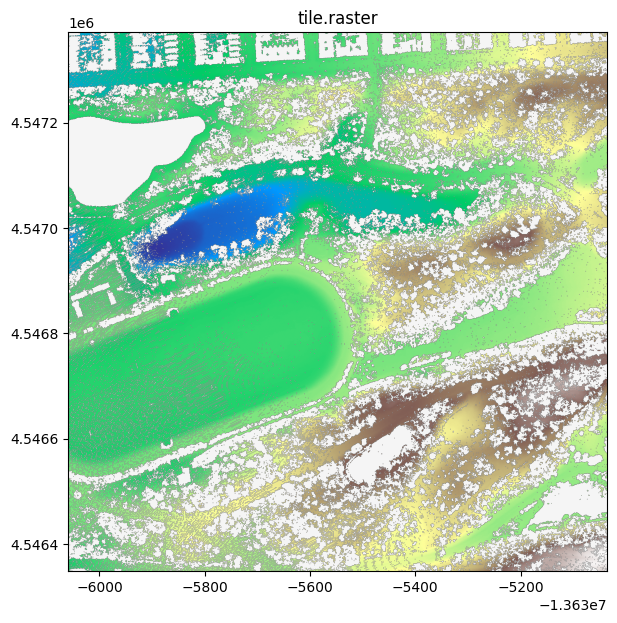

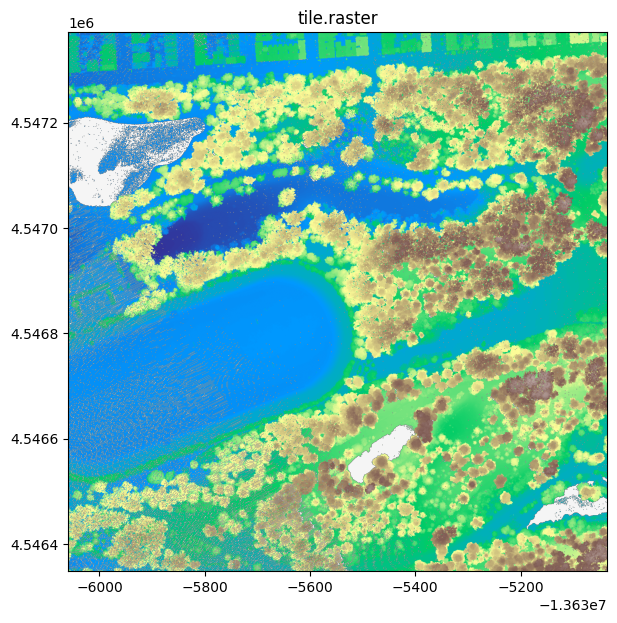

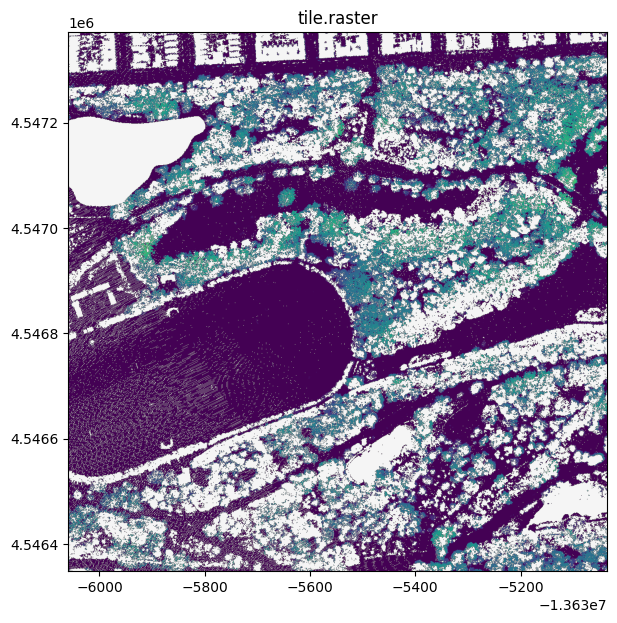

In [0]:
# Locate the tile covering Golden Gate Park and render its DTM, DSM, and CHM.
_gx, _gy = lonlat_to_3857(-122.486, 37.769)
_tx, _ty = int((_gx - X0) // TILE_M), int((_gy - Y0) // TILE_M)
_sel = (F.col("tx") == _tx) & (F.col("ty") == _ty)

dtm_t = dtm.where(_sel).first()
dsm_t = dsm.where(_sel).first()
chm_t = chm.where(_sel).first()
print(f"sample tile tx={_tx} ty={_ty}  (Golden Gate Park)")

if dtm_t: plot_raster(dtm_t["dtm"]["raster"], cmap="terrain", fig_w=7, fig_h=7)
if dsm_t: plot_raster(dsm_t["dsm"]["raster"], cmap="terrain", fig_w=7, fig_h=7)
if chm_t: plot_raster(chm_t["chm"]["raster"], cmap="viridis", fig_w=7, fig_h=7)

## (Optional) Write CHM tiles to the Volume

Persist the CHM as GeoTIFF tiles via the GeoBrix `gtiff_gbx` writer (it takes exactly `(source, tile)` and emits `<source>.tif`) for downstream reuse — the coverage analytics in later parts read these surfaces. Off by default.

In [0]:
WRITE_SURFACES = False
if WRITE_SURFACES:
    OUT_DIR = "/Volumes/geospatial_docs/geobrix/sample-data/geobrix-examples/sf/lidar-surfaces/chm"
    (chm.select(F.concat_ws("_", F.lit("chm"), "tx", "ty").alias("source"), F.col("chm").alias("tile"))
        .write.format("gtiff_gbx").mode("overwrite").save(OUT_DIR))
    print("wrote CHM tiles ->", OUT_DIR)

## Summary

Straight from a classified LiDAR point cloud we produced a **Canopy Height Model** over all of San Francisco — bin ground returns (`min`) for bare earth, bin all returns (`max`) for the surface, and `rst_chm` to difference them — with **per-tile distributed binning** as the big-data pattern. No external DEM product, no coverage gaps.

**Next:** Part 2 writes the DSM and DTM as reusable GeoTIFF products (and compares a TIN bare-earth ground); later parts add wireless-coverage analytics (antenna siting, `rst_viewshed`) over these surfaces.